In [5]:
import cv2
import mediapipe as mp

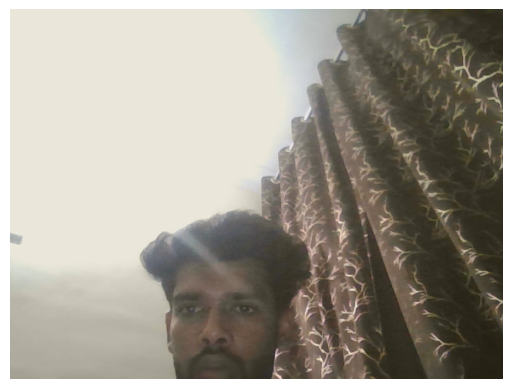

In [7]:
import cv2
import mediapipe as mp
import matplotlib.pyplot as plt

mp_drawing = mp.solutions.drawing_utils
mp_hands = mp.solutions.hands

# Open webcam
cap = cv2.VideoCapture(0)

# MediaPipe Hands initialization
p = mp_hands.Hands(static_image_mode=True, max_num_hands=2, min_detection_confidence=0.5)

def position_data(lmlist):
    global wrist, thumb_tip, index_mcp, index_tip, midle_tip, ring_tip
    pass  # You can implement this function later if needed

while True:
    ret, frame = cap.read()
    if not ret:
        break

    frame = cv2.flip(frame, 1)  # Mirror the image
    img_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    result = p.process(img_rgb)

    if result.multi_hand_landmarks:
        for hand_landmarks in result.multi_hand_landmarks:
            mp_drawing.draw_landmarks(
                frame,
                hand_landmarks,
                mp_hands.HAND_CONNECTIONS
            )

    # Convert frame to RGB for matplotlib
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    # Display the image using matplotlib
    plt.imshow(frame_rgb)
    plt.axis('off')
    plt.show()

    # Break the loop (optional, as Jupyter doesn't handle cv2.waitKey well)
    break  # This will only show one frame; remove it if you want to loop

# Cleanup
cap.release()
cv2.destroyAllWindows()
